In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
full_df = pd.read_csv('final_full_data_centered.csv')

In [5]:
def get_full_numpy_array(local_fits_path):
    try:
        with fits.open(local_fits_path, memmap=False) as hdul:
            
            # find first HDU with data
            for hdu in hdul:
                if hdu.data is not None:
                    im = np.array(hdu.data).squeeze()
                    break
            else:
                print(f"No image data found in {local_fits_path}")
                return None

            # mask invalid values (NaNs, infs)
            im = np.ma.masked_invalid(im)

            return im

    except Exception as e:
        print(f"An error occurred while processing {local_fits_path}: {e}")
        return None

In [31]:
path = r"C:\Research\bts_vlass_cross_matching\dillon_extracting_files\dillon_fits\ztf_cutouts\ztf_cutouts_no_interp\ZTF17aaazdba_epoch_3.fits"

arr = get_full_numpy_array(path)

In [32]:
def calculate_rms(arr, sig_value = 4, n_iter = 4):
    mask = np.ones(arr.shape, dtype=bool)

    for _ in range(n_iter):
        data = arr[mask]
        median = np.median(data)
        std = np.std(data)

        mask = np.abs(arr - median) <= sig_value * std
        print(mask)

    rms = np.std(arr[mask])
    
    return mask

In [43]:
import numpy as np

def calculate_rms(arr, sig_value=4, n_iter=4):
    mask = np.ones(arr.shape, dtype=bool)
    masks = []  # store each iteration

    for i in range(n_iter):
        data = arr[mask]
        median = np.median(data)
        std = np.std(data)

        mask = np.abs(arr - median) <= sig_value * std
        masks.append(mask.copy())  # save snapshot

    rms = np.std(arr[mask])
    return rms, masks

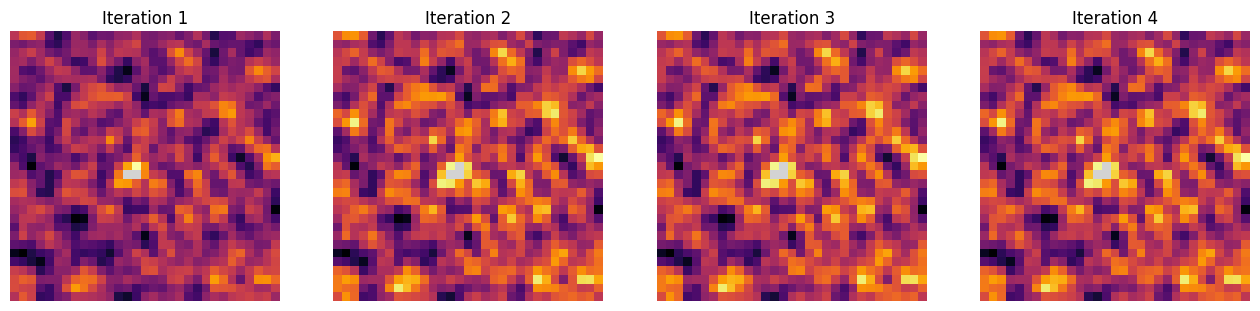

In [44]:
import matplotlib.pyplot as plt

rms, masks = calculate_rms(arr)

fig, axes = plt.subplots(1, len(masks), figsize=(4*len(masks), 4))

for i, mask in enumerate(masks):
    masked_arr = arr.copy()
    masked_arr[~mask] = np.nan

    cmap = plt.cm.inferno.copy()
    cmap.set_bad(color='lightgray')

    axes[i].imshow(masked_arr, origin='lower', cmap=cmap)
    axes[i].set_title(f"Iteration {i+1}")
    axes[i].axis('off')

plt.show()

## Check peak luminosity location

This reads the saved luminosity arrays from `File Path` in `final_full_data_centered.csv` and checks whether the peak being recorded is the center pixel or the maximum in the central 3x3 region. It also records where the full-image global maximum lands so off-center bright pixels are easy to inspect.


In [ ]:
from pathlib import Path

CENTER_CHECK_CSV = "final_full_data_centered.csv"


def check_centered_peak_locations(csv_path=CENTER_CHECK_CSV):
    df = pd.read_csv(csv_path)
    rows = []
    unusable_rows = []

    for row_idx, row in df.iterrows():
        array_path = Path(row["File Path"])
        if not array_path.exists():
            unusable_rows.append({
                "row": row_idx,
                "Name": row["Name"],
                "Epoch": row["Epoch"],
                "reason": "missing file",
                "File Path": row["File Path"],
            })
            continue

        arr = np.asarray(np.load(array_path), dtype=float)
        if arr.ndim != 2 or not np.isfinite(arr).any():
            unusable_rows.append({
                "row": row_idx,
                "Name": row["Name"],
                "Epoch": row["Epoch"],
                "reason": f"no finite 2D data; shape={arr.shape}",
                "File Path": row["File Path"],
            })
            continue

        height, width = arr.shape
        center_y, center_x = height // 2, width // 2
        y0, y1 = max(0, center_y - 1), min(height, center_y + 2)
        x0, x1 = max(0, center_x - 1), min(width, center_x + 2)

        finite_arr = np.where(np.isfinite(arr), arr, -np.inf)
        global_y, global_x = np.unravel_index(np.argmax(finite_arr), arr.shape)
        global_max = arr[global_y, global_x]

        center_box = arr[y0:y1, x0:x1]
        finite_box = np.where(np.isfinite(center_box), center_box, -np.inf)
        box_y_rel, box_x_rel = np.unravel_index(np.argmax(finite_box), center_box.shape)
        box_y, box_x = y0 + box_y_rel, x0 + box_x_rel
        center_3x3_max = arr[box_y, box_x]

        csv_peak = row["Peak Luminosity"]
        rows.append({
            "row": row_idx,
            "Name": row["Name"],
            "Epoch": row["Epoch"],
            "shape": arr.shape,
            "csv_peak": csv_peak,
            "center_val": arr[center_y, center_x],
            "center_3x3_max": center_3x3_max,
            "center_3x3_max_y": box_y,
            "center_3x3_max_x": box_x,
            "global_max": global_max,
            "global_max_y": global_y,
            "global_max_x": global_x,
            "center_y": center_y,
            "center_x": center_x,
            "global_max_in_center": (global_y, global_x) == (center_y, center_x),
            "global_max_in_center_3x3": y0 <= global_y < y1 and x0 <= global_x < x1,
            "csv_matches_center": np.isclose(csv_peak, arr[center_y, center_x], rtol=1e-10, atol=0),
            "csv_matches_center_3x3_max": np.isclose(csv_peak, center_3x3_max, rtol=1e-10, atol=0),
            "csv_matches_global_max": np.isclose(csv_peak, global_max, rtol=1e-10, atol=0),
            "File Path": row["File Path"],
            "fits_path": row["fits_path"],
        })

    checks = pd.DataFrame(rows)
    unusable = pd.DataFrame(unusable_rows)

    checks.to_csv("center_peak_check.csv", index=False)
    unusable.to_csv("center_peak_check_unusable_arrays.csv", index=False)
    checks.loc[~checks["global_max_in_center_3x3"]].to_csv(
        "center_peak_check_global_max_outside_3x3.csv", index=False
    )
    checks.loc[~checks["csv_matches_center_3x3_max"]].to_csv(
        "center_peak_check_csv_peak_not_3x3_max.csv", index=False
    )

    finite_csv_peak = np.isfinite(checks["csv_peak"])
    finite_center_3x3_max = np.isfinite(checks["center_3x3_max"])
    summary = pd.Series({
        "rows in CSV": len(df),
        "usable arrays": len(checks),
        "unusable arrays": len(unusable),
        "usable arrays with finite CSV peak": finite_csv_peak.sum(),
        "usable arrays with finite center 3x3 max": finite_center_3x3_max.sum(),
        "CSV peak equals center pixel": checks["csv_matches_center"].sum(),
        "CSV peak equals center 3x3 max": checks["csv_matches_center_3x3_max"].sum(),
        "CSV peak equals full-image global max": checks["csv_matches_global_max"].sum(),
        "full-image global max in center pixel": checks["global_max_in_center"].sum(),
        "full-image global max in center 3x3": checks["global_max_in_center_3x3"].sum(),
    })

    return checks, unusable, summary


center_peak_checks, unusable_peak_arrays, center_peak_summary = check_centered_peak_locations()
display(center_peak_summary)
display(center_peak_checks.loc[~center_peak_checks["global_max_in_center_3x3"]].head(20))
display(unusable_peak_arrays.head(20))
